In [28]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import sklearn


In [29]:
X=pd.read_csv(r'/Users/marc-antoine/Desktop/3A/CS/Machine Learning B/TP 1/bardet_x.csv')
y=pd.read_csv(r'/Users/marc-antoine/Desktop/3A/CS/Machine Learning B/TP 1/bardet_y.csv')

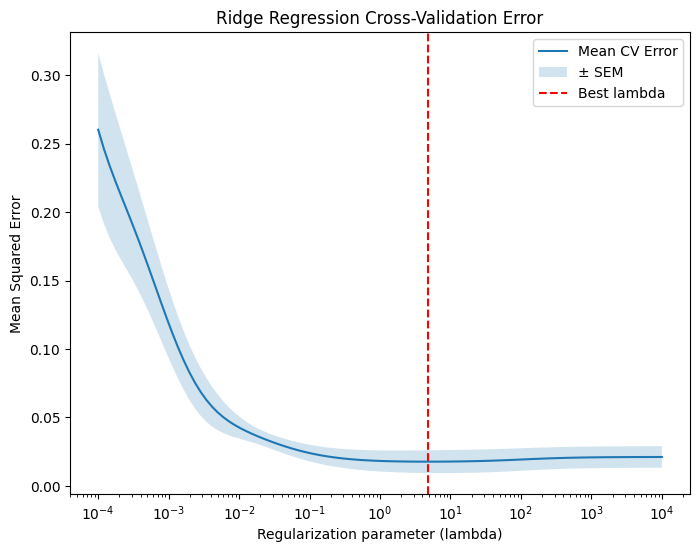

In [30]:
#Ridge regression with cross-validation
from sklearn import linear_model
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
lambdas = np.logspace(-4, 4, 100)
gridsearch = GridSearchCV(Ridge(),param_grid={'alpha':lambdas},cv=5,scoring='neg_mean_squared_error')
gridsearch.fit(X,y.values.ravel())
mse_mean = -gridsearch.cv_results_['mean_test_score']
mse_std = gridsearch.cv_results_['std_test_score']
n_folds = gridsearch.n_splits_
sem = mse_std / np.sqrt(n_folds)
#Plot of the cross validation error as a function of the regularization parameter
#And the best value of the regularization parameter
plt.figure(figsize=(8,6))
plt.semilogx(lambdas, mse_mean, label='Mean CV Error')
plt.fill_between(lambdas, mse_mean - sem, mse_mean + sem, alpha=0.2, label='± SEM')
plt.axvline(gridsearch.best_params_['alpha'], color='r', linestyle='--', label='Best lambda')
plt.xlabel('Regularization parameter (lambda)')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Regression Cross-Validation Error')
plt.legend()
plt.show()


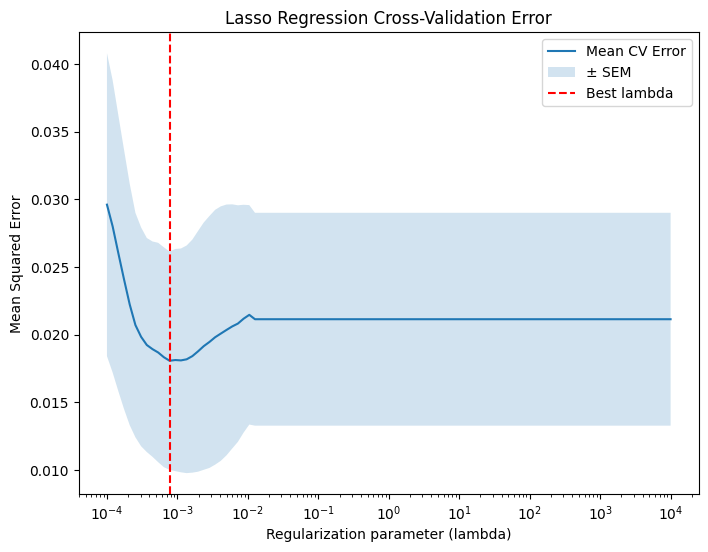

In [31]:
#Same with lasso regression
from sklearn.linear_model import Lasso
gridsearch_lasso = GridSearchCV(Lasso(max_iter=10000),param_grid={'alpha':lambdas},cv=5,scoring='neg_mean_squared_error')
gridsearch_lasso.fit(X,y.values.ravel())
mse_mean_lasso = -gridsearch_lasso.cv_results_['mean_test_score']
mse_std_lasso = gridsearch_lasso.cv_results_['std_test_score']
n_folds_lasso = gridsearch_lasso.n_splits_
sem_lasso = mse_std_lasso / np.sqrt(n_folds_lasso)
#Plot of the cross validation error as a function of the regularization parameter
#And the best value of the regularization parameter
plt.figure(figsize=(8,6))
plt.semilogx(lambdas, mse_mean_lasso, label='Mean CV Error')
plt.fill_between(lambdas, mse_mean_lasso - sem_lasso, mse_mean_lasso + sem_lasso, alpha=0.2, label='± SEM')
plt.axvline(gridsearch_lasso.best_params_['alpha'], color='r', linestyle='--', label='Best lambda')
plt.xlabel('Regularization parameter (lambda)')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Regression Cross-Validation Error')
plt.legend()
plt.show()

In [ ]:
# Outlier check: is a specific observation driving the large CV variance (SEM)?
from scipy import stats
from sklearn.model_selection import cross_val_predict, LeaveOneOut

y_vals = y.values.ravel()

# 1) Simple univariate check on the response y
z_scores = np.abs(stats.zscore(y_vals))
print("Observations with |z-score(y)| > 2:", np.where(z_scores > 2)[0])

plt.figure(figsize=(6, 3))
plt.boxplot(y_vals, vert=False)
plt.title('Boxplot of y (response)')
plt.xlabel('y')
plt.show()

# 2) Per-observation LOOCV error at the best Lasso alpha: flags points that are hard
# to predict from X (not just extreme in y), which is what actually inflates fold-level MSE
best_alpha_lasso = gridsearch_lasso.best_params_['alpha']
y_pred_loo = cross_val_predict(Lasso(alpha=best_alpha_lasso, max_iter=10000), X, y_vals, cv=LeaveOneOut())
sq_err_loo = (y_pred_loo - y_vals) ** 2

plt.figure(figsize=(10, 4))
plt.bar(range(len(sq_err_loo)), sq_err_loo)
plt.axhline(sq_err_loo.mean(), color='r', linestyle='--', label='mean LOOCV squared error')
plt.xlabel('Observation index')
plt.ylabel('LOOCV squared error')
plt.title('Per-observation LOOCV error (Lasso at best alpha)')
plt.legend()
plt.show()

outlier_idx = np.argsort(-sq_err_loo)[:5]
print("Top 5 hardest-to-predict observations (LOOCV):")
for i in outlier_idx:
    ratio = sq_err_loo[i] / sq_err_loo.mean()
    print(f"  idx={i}: y={y_vals[i]:.3f}, pred={y_pred_loo[i]:.3f}, sq_err={sq_err_loo[i]:.4f} ({ratio:.1f}x mean)")


In [ ]:
#Same with elastic net regression
from sklearn.linear_model import ElasticNet
l1_ratios = np.linspace(0.01, 1, 20)  # l1_ratio must stay in [0, 1] (0=ridge, 1=lasso)
gridsearch_elastic = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid={'alpha': lambdas, 'l1_ratio': l1_ratios},
    cv=5,
    scoring='neg_mean_squared_error'
)
gridsearch_elastic.fit(X, y.values.ravel())

# alpha varies more slowly than l1_ratio in cv_results_ (alphabetical order of keys)
mse_grid_elastic = -gridsearch_elastic.cv_results_['mean_test_score'].reshape(len(lambdas), len(l1_ratios))
std_grid_elastic = gridsearch_elastic.cv_results_['std_test_score'].reshape(len(lambdas), len(l1_ratios))

best_alpha = gridsearch_elastic.best_params_['alpha']
best_l1 = gridsearch_elastic.best_params_['l1_ratio']
best_l1_idx = np.argmin(np.abs(l1_ratios - best_l1))

mse_mean_elastic = mse_grid_elastic[:, best_l1_idx]
sem_elastic = std_grid_elastic[:, best_l1_idx] / np.sqrt(gridsearch_elastic.n_splits_)

#Plot of the cross validation error as a function of alpha, at the optimal l1_ratio fixed
plt.figure(figsize=(8,6))
plt.semilogx(lambdas, mse_mean_elastic, label=f'Mean CV Error (l1_ratio={best_l1:.2f})')
plt.fill_between(lambdas, mse_mean_elastic - sem_elastic, mse_mean_elastic + sem_elastic, alpha=0.2, label='± SEM')
plt.axvline(best_alpha, color='r', linestyle='--', label='Best lambda')
plt.xlabel('Regularization parameter (lambda)')
plt.ylabel('Mean Squared Error')
plt.title('Elastic Net Regression Cross-Validation Error')
plt.legend()
plt.show()

In [ ]:
#Visualization of the variable groups (genes) selected by elastic net
best_elastic = gridsearch_elastic.best_estimator_
coefs = best_elastic.coef_
coefs_grouped = coefs.reshape(20, 5)  # 20 candidate genes x 5 B-spline basis functions

# Heatmap of coefficients by gene / basis function
vmax = np.abs(coefs).max()
plt.figure(figsize=(10, 6))
plt.imshow(coefs_grouped, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(label='Coefficient')
plt.xlabel('B-spline basis function (1 to 5)')
plt.ylabel('Candidate gene')
plt.yticks(range(20), [f'Gene {i+1}' for i in range(20)])
plt.xticks(range(5), [f'{j+1}' for j in range(5)])
plt.title('Elastic Net coefficients by gene and basis function')
plt.show()

# Number of non-zero coefficients per gene: full selection (5/5), partial, or none
n_nonzero_per_gene = np.sum(coefs_grouped != 0, axis=1)
colors = ['#2c7fb8' if n == 5 else '#d9d9d9' if n == 0 else '#f16913' for n in n_nonzero_per_gene]

plt.figure(figsize=(10, 6))
plt.bar(range(1, 21), n_nonzero_per_gene, color=colors)
plt.axhline(5, color='k', linestyle='--', linewidth=1, label='Full group (5/5)')
plt.xlabel('Candidate gene')
plt.ylabel('Number of non-zero coefficients (out of 5)')
plt.xticks(range(1, 21))
plt.title('Gene-level selection — elastic net (blue = full group, orange = partial selection, gray = not selected)')
plt.legend()
plt.show()

print(f"Genes not selected (0/5): {np.sum(n_nonzero_per_gene == 0)}")
print(f"Genes partially selected (1 to 4 out of 5): {np.sum((n_nonzero_per_gene > 0) & (n_nonzero_per_gene < 5))}")
print(f"Genes fully selected (5/5): {np.sum(n_nonzero_per_gene == 5)}")


In [ ]:
#Group Lasso (pip install group-lasso), with 20 groups of size pg=5
from group_lasso import GroupLasso
groups = np.repeat(np.arange(20), 5)  # groups[i] = gene index (0 to 19) of column i

lambdas_group = np.logspace(-4, 2, 100)  # different scale from "lambdas" (group_reg has a different useful range)
gl = GroupLasso(groups=groups, l1_reg=0, n_iter=10000, supress_warning=False)  # l1_reg=0 -> pure group Lasso (not sparse group lasso)

gridsearch_group = GridSearchCV(gl, param_grid={'group_reg': lambdas_group}, cv=5, scoring='neg_mean_squared_error')
gridsearch_group.fit(X, y.values.ravel())

mse_mean_group = -gridsearch_group.cv_results_['mean_test_score']
mse_std_group = gridsearch_group.cv_results_['std_test_score']
sem_group = mse_std_group / np.sqrt(gridsearch_group.n_splits_)

plt.figure(figsize=(8,6))
plt.semilogx(lambdas_group, mse_mean_group, label='Mean CV Error')
plt.fill_between(lambdas_group, mse_mean_group - sem_group, mse_mean_group + sem_group, alpha=0.2, label='± SEM')
plt.axvline(gridsearch_group.best_params_['group_reg'], color='r', linestyle='--', label='Best lambda')
plt.xlabel('Regularization parameter (lambda)')
plt.ylabel('Mean Squared Error')
plt.title('Group Lasso Regression Cross-Validation Error')
plt.legend()
plt.show()

# Genes selected by group Lasso (whole group selected or not, by construction)
best_group_model = gridsearch_group.best_estimator_
coefs_group = best_group_model.coef_.ravel()
coefs_group_grouped = coefs_group.reshape(20, 5)
genes_selected_group = np.where(np.any(coefs_group_grouped != 0, axis=1))[0] + 1
print(f"Candidate genes selected by group Lasso: {genes_selected_group}")
print(f"Number of genes selected: {len(genes_selected_group)} / 20")

# Visual comparison with the (potentially partial) elastic net pattern
vmax = np.abs(coefs_group).max()
plt.figure(figsize=(10, 6))
plt.imshow(coefs_group_grouped, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(label='Coefficient')
plt.xlabel('B-spline basis function (1 to 5)')
plt.ylabel('Candidate gene')
plt.yticks(range(20), [f'Gene {i+1}' for i in range(20)])
plt.xticks(range(5), [f'{j+1}' for j in range(5)])
plt.title('Group Lasso coefficients by gene and basis function')
plt.show()

# Number of non-zero coefficients per gene: must be 0 or 5 (never in between) for group Lasso
n_nonzero_per_gene_group = np.sum(coefs_group_grouped != 0, axis=1)
colors_group = ['#2c7fb8' if n == 5 else '#d9d9d9' if n == 0 else '#f16913' for n in n_nonzero_per_gene_group]

plt.figure(figsize=(10, 6))
plt.bar(range(1, 21), n_nonzero_per_gene_group, color=colors_group)
plt.axhline(5, color='k', linestyle='--', linewidth=1, label='Full group (5/5)')
plt.xlabel('Candidate gene')
plt.ylabel('Number of non-zero coefficients (out of 5)')
plt.xticks(range(1, 21))
plt.title('Gene-level selection — group Lasso (all-or-nothing per group, no orange bars expected)')
plt.legend()
plt.show()


In [ ]:
#Comparison of the 4 models (Ridge, Lasso, Elastic Net, Group Lasso) in terms of mean MSE and standard error
mse_means = [mse_mean[np.argmin(mse_mean)], mse_mean_lasso[np.argmin(mse_mean_lasso)], mse_mean_elastic[np.argmin(mse_mean_elastic)], mse_mean_group[np.argmin(mse_mean_group)]]
sem_means = [sem[np.argmin(mse_mean)], sem_lasso[np.argmin(mse_mean_lasso)], sem_elastic[np.argmin(mse_mean_elastic)], sem_group[np.argmin(mse_mean_group)]]
print("Model comparison:")
for model_name, mse_val, sem_val in zip(['Ridge', 'Lasso', 'Elastic Net', 'Group Lasso'], mse_means, sem_means):
    print(f"{model_name}: Mean MSE = {mse_val:.4f}, Standard error = {sem_val:.4f}")